In [ ]:
!pip3 install cobra
!pip3 install cvxpylayers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 29.2 MB/s eta 0:00:00
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [ ]:
# connect to drive
from google.colab import drive
drive.mount('/content/drive')
parentdir = "/content/drive/MyDrive/Colab Notebooks/FBANet/"

Mounted at /content/drive


In [ ]:
import cvxpy as cp
import cobra as cb
from cobra.util.array import create_stoichiometric_matrix
from cvxpylayers.torch import CvxpyLayer
import torch

# Load the model
# model = cb.io.load_json_model("../Cobra_Models/Univ_GPR_Model.json")
model = cb.io.load_json_model(parentdir+"GPR_model_1a.json")
slack_penalty = 10  # Penalty for slack variables

# Extract the stoichiometric matrix and the bounds
S = create_stoichiometric_matrix(model, array_type="dok")
lower_bounds = model.reactions.list_attr("lower_bound")
upper_bounds = model.reactions.list_attr("upper_bound")

n_rxns = S.shape[1]
n_mets = S.shape[0]

# Define the optimization variables
v = cp.Variable(n_rxns)
slack_lb  = cp.Variable(n_rxns, nonneg=True)  # Slack variables for lower bounds
slack_ub = cp.Variable(n_rxns, nonneg=True)  # Slack variables for upper bounds

# add params for lower and upper bounds
lb = cp.Parameter(n_rxns)
ub = cp.Parameter(n_rxns)
lb.value = lower_bounds
ub.value = upper_bounds

# Define the constraints
constraints = [
    S @ v == 0,
    v >= lb - slack_lb,
    v <= ub + slack_ub
]

# Define the objective function (maximize the flux through the biomass reaction)
biomass_index = model.reactions.index("bio1(c)")
objective = cp.Maximize(v[biomass_index] - slack_penalty * (cp.sum(slack_lb) + cp.sum(slack_ub)))  # Penalize slack variables

# Define the optimization problem
problem = cp.Problem(objective, constraints)

# Create a CVXPY layer
layer = CvxpyLayer(problem, parameters=[lb, ub], variables=[v, slack_lb, slack_ub])

# Example input for the layer (using the original bounds)
input_lb = torch.tensor(lower_bounds)
input_ub = torch.tensor(upper_bounds)

# Forward pass through the layer
solution, slack_lb, slack_ub = layer(input_lb, input_ub)

# mapped back to reaction names
reaction_names = [rxn.id for rxn in model.reactions]
flux_dict = {reaction_names[i]: solution[i].item() for i in range(n_rxns)}
for rxn, flux in flux_dict.items():
    print(f"{rxn}: {flux}")


EX_A(e): -500.00000214406174
EX_B(e): -500.00000214403457
T_A: 500.00000214251696
T_B: -500.00000214248996
T_Bio: 1000.0000042707296
AtoPrebio(c): 500.0000021394399
BtoPrebio(c): 500.0000021394128
bio1(c): 1000.0000042736339
EX_Bio(e): 1000.0000042692762


In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

class ICNN_Block(nn.Module):
    def __init__(self, n_input, n_bounds, n_hidden_layers, hidden_layer_size, activation_type='relu'):
        super(ICNN_Block, self).__init__()
        # Select activation
        self.act = F.relu if activation_type == 'relu' else F.leaky_relu

        self.first_layer = nn.Linear(n_input, hidden_layer_size)
        # layers
        self.z_layers = nn.ModuleList([nn.Linear(hidden_layer_size, hidden_layer_size, bias=False) for _ in range(n_hidden_layers - 1)])
        # skip connections
        self.x_layers = nn.ModuleList([nn.Linear(n_input, hidden_layer_size, bias=True) for _ in range(n_hidden_layers - 1)])

        # output
        self.final_z = nn.Linear(hidden_layer_size, n_bounds, bias=False)
        self.final_x = nn.Linear(n_input, n_bounds, bias=True)

    def forward(self, x):
        z = self.act(self.first_layer(x))
        for z_layer, x_layer in zip(self.z_layers, self.x_layers):
            z = self.act(z_layer(z) + x_layer(x))
        return self.final_z(z) + self.final_x(x)

    def enforce_convexity(self):
        """Projects weights to non-negative orthant."""
        with torch.no_grad():
            for layer in self.z_layers:
                layer.weight.clamp_(min=0)
            self.final_z.weight.clamp_(min=0)


class FBA_Net(nn.Module):
    """Main network containing the two ICNN blocks and the CVXPY layer."""
    def __init__(self, cvxpylayer, n_input, n_bounds, n_hidden_layers, hidden_layer_size, activation_type='relu'):
        super(FBA_Net, self).__init__()
        self.cvxpylayer = cvxpylayer

        # Instantiate two completely separate ICNN architectures
        self.lower_icnn = ICNN_Block(n_input, n_bounds, n_hidden_layers, hidden_layer_size)
        self.delta_icnn = ICNN_Block(n_input, n_bounds, n_hidden_layers, hidden_layer_size)

    def forward(self, x):
        # --- Independent ICNN Forward Passes ---
        # Both outputs will have shape: (batch_size, n_bounds)
        lb = self.lower_icnn(x)
        delta = self.delta_icnn(x)

        ub = lb + delta  # Ensure upper bound is always above lower bound

        # --- CVXPY Layer Pass ---
        # Move lb and ub to CPU before passing to cvxpylayer
        solution, slack_lb, slack_ub = self.cvxpylayer(lb.cpu(), ub.cpu())

        return solution, slack_lb, slack_ub, lb, ub

    def enforce_convexity(self):
        """Call this after optimizer.step() to apply constraints to both blocks."""
        self.lower_icnn.enforce_convexity()
        self.delta_icnn.enforce_convexity()

class FBA_NET_Loss(nn.Module):
    """Custom loss function combining MSE, slack penalties, and weight sparsity."""
    def __init__(self):
        super(FBA_NET_Loss, self).__init__()
        self.mse_loss = nn.MSELoss()

    def forward(self, y_pred, y_true, slack_lb, slack_ub, model, current_slack_weight, current_sparse_weight):
        self.mse_loss_val = self.mse_loss(y_pred, y_true)
        self.slack_penalty = current_slack_weight * torch.mean(torch.sum(slack_lb + slack_ub, dim=1))

        # Apply L1 penalty to the weights of the model
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        self.sparse_weight_loss = current_sparse_weight * l1_norm

        return self.mse_loss_val + self.slack_penalty + self.sparse_weight_loss

    def get_mse(self):
        return self.mse_loss_val.detach()

    def get_slack_penalty(self):
        return self.slack_penalty.detach()

    def get_sparse_weight_loss(self):
        return self.sparse_weight_loss.detach()


In [ ]:
import pandas as pd
import numpy as np

# data
df = pd.read_csv(parentdir+"simulated_data_mdl_1a.csv")

# columns are "g1", "g2", ..., "media1", "media2", ..., "flux"
# make useable for NN
x = df.drop(columns=["Objective"]).values  # shape: (num_samples, n_input)
y = df["Objective"].values  # shape: (num_samples,)

# Define the model
n_input = x.shape[1]
n_bounds = n_rxns  # number of reactions
n_hidden_layers = 5
hidden_layer_size = 32
model = FBA_Net(layer, n_input, n_bounds, n_hidden_layers, hidden_layer_size).double()
target_flux_idx = reaction_names.index("bio1(c)")  # Index of the biomass reaction in the solution vector

In [ ]:
# Loss configs: Warm-up Strategy
# Start penalties low to allow the model to explore and find the correct objective first
initial_slack_loss_weight = 25
initial_sparse_bounds_weight = 0.1
crit = FBA_NET_Loss() # Instantiate crit without weights

# training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 500

# tracking
mse_losses = np.zeros(num_epochs)
slack_losses = np.zeros(num_epochs)
sparse_weight_losses = np.zeros(num_epochs) # Renamed to reflect weight sparsity

# Define final weights to ramp up to (forcing strict feasibility later in training)
final_slack_loss_weight = 2
final_sparse_bounds_weight = 0.1

grad_tol = 1e-4  # Gradient tolerance for early stopping
clip_max_norm = 10 # Max norm for gradient clipping

# training
for epoch in range(num_epochs):
    # Calculate dynamic weights for the current epoch (Ramping Up)
    current_slack_weight = initial_slack_loss_weight + \
                           (final_slack_loss_weight - initial_slack_loss_weight) * (epoch / (num_epochs - 1))
    current_sparse_weight = initial_sparse_bounds_weight + \
                            (final_sparse_bounds_weight - initial_sparse_bounds_weight) * (epoch / (num_epochs - 1))

    model.train()
    optimizer.zero_grad()

    # Forward pass
    x_device = torch.tensor(x, dtype=torch.double).to(device)
    solution, slack_lb, slack_ub, lb, ub = model(x_device)

    y_pred = solution[:, target_flux_idx]  # Extract the predicted flux for the biomass reaction
    y_pred = y_pred.to(device) # Ensure y_pred is on device
    y_true = torch.tensor(y, dtype=torch.double).to(device) # Move y_true to the device

    # Compute loss (MSE between predicted flux and true objective)
    # Pass 'model' instead of 'lb' and 'ub'
    loss = crit(y_pred, y_true,
                 slack_lb, slack_ub,
                 model,
                 current_slack_weight, current_sparse_weight) # Pass dynamic weights

    # Backward pass
    loss.backward()

    # Apply Gradient Clipping AND calculate total norm simultaneously
    total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_max_norm).item()

    # Optimization step
    optimizer.step()

    # Enforce convexity constraints on the ICNN weights
    model.enforce_convexity()

    # report
    mse_losses[epoch] = crit.get_mse().cpu().item() # Move to CPU and get item
    slack_losses[epoch] = crit.get_slack_penalty().cpu().item()/current_slack_weight # Move to CPU and get item
    sparse_weight_losses[epoch] = crit.get_sparse_weight_loss().cpu().item()/current_sparse_weight # Move to CPU and get item
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss.item():>12.4f} | MSE: {mse_losses[epoch]:>12.4f} | Slack: {slack_losses[epoch]:>10.4f} | Weight L1: {sparse_weight_losses[epoch]:>10.4f} | Grad Norm: {total_norm:>8.4f}")

    # Check early stopping criterion
    if total_norm < grad_tol:
        print(f"\nEarly stopping triggered at epoch {epoch+1} as gradient norm ({total_norm:.6f}) is below tolerance ({grad_tol}).")
        # Truncate tracking arrays
        mse_losses = mse_losses[:epoch+1]
        slack_losses = slack_losses[:epoch+1]
        sparse_weight_losses = sparse_weight_losses[:epoch+1]
        break


Epoch 1/500 | Loss:   14308.4709 | MSE:    9203.3409 | Slack:   198.9190 | Weight L1:  1321.5476 | Grad Norm: 21058.3240
Epoch 2/500 | Loss:    8548.7733 | MSE:    2395.9119 | Slack:   242.8700 | Weight L1:   927.9348 | Grad Norm: 26019.4101
Epoch 3/500 | Loss:    8232.4533 | MSE:    2355.7033 | Slack:   232.2636 | Weight L1:   925.0157 | Grad Norm: 27395.5082
Epoch 4/500 | Loss:    7841.9519 | MSE:    2268.2554 | Slack:   220.5373 | Weight L1:   920.8583 | Grad Norm: 27514.5225
Epoch 5/500 | Loss:    7449.5916 | MSE:    2177.0549 | Slack:   208.8441 | Weight L1:   916.1342 | Grad Norm: 21561.1027
Epoch 6/500 | Loss:    7125.5359 | MSE:    2145.1157 | Slack:   197.4678 | Weight L1:   912.1232 | Grad Norm: 19522.6259
Epoch 7/500 | Loss:    6784.6569 | MSE:    2080.8802 | Slack:   186.6682 | Weight L1:   909.4077 | Grad Norm: 18379.2112
Epoch 8/500 | Loss:    6473.0651 | MSE:    2037.6289 | Slack:   176.1621 | Weight L1:   906.9369 | Grad Norm: 22426.2051
Epoch 9/500 | Loss:    6184.7804

In [ ]:
# save weights and losses for transfer learning
id = "best_1"
losses = {
    "id": id,
    "mse_losses": mse_losses,
    "slack_losses": slack_losses,
    "sparse_weight_losses": sparse_weight_losses,
    "initial_slack_loss_weight": initial_slack_loss_weight,
    "initial_sparse_bounds_weight": initial_sparse_bounds_weight,
    "final_sparse_bounds_weight": final_sparse_bounds_weight,
    "final_slack_loss_weight": final_slack_loss_weight,
    "loss weight decay": "linear weight decay"
}
np.save(parentdir+f"losses_{id}.npz", losses)
torch.save(model.state_dict(), parentdir+f"model_{id}.pt")

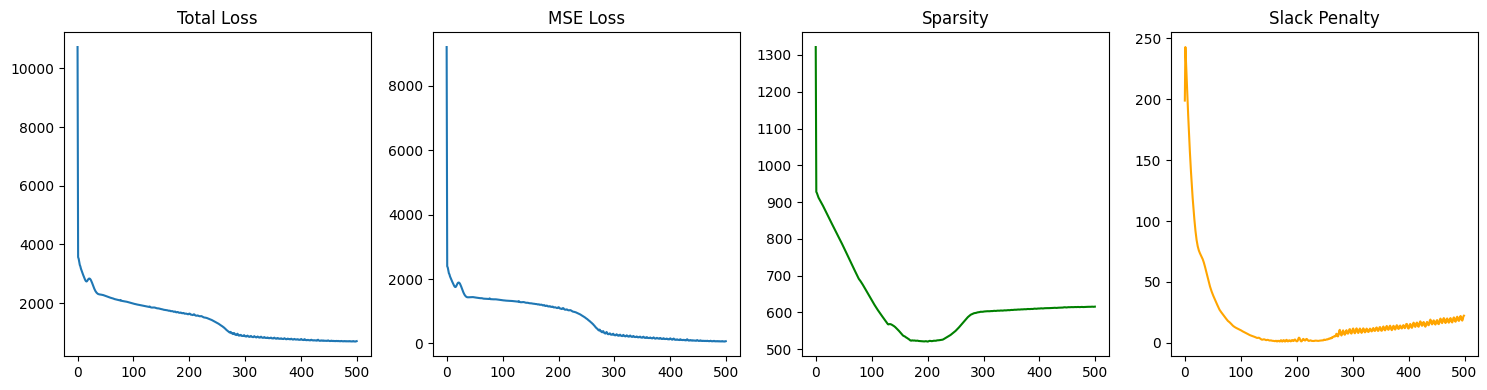

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
axs = axs.flatten()
axs[0].plot(mse_losses + sparse_weight_losses + slack_losses)
axs[0].set_title("Total Loss")
axs[1].plot(mse_losses, label="MSE Loss")
axs[1].set_title("MSE Loss")
axs[2].plot(sparse_weight_losses, label="Sparse Weight Loss", color="green")
axs[2].set_title("Sparsity")
axs[3].plot(slack_losses, label="Slack Penalty", color="orange")
axs[3].set_title("Slack Penalty")
plt.tight_layout()
plt.show()

In [ ]:
# test forward pass after training
eval_idx = 100
target_flux_idx = reaction_names.index("bio1(c)")  # Index of the biomass reaction in the solution vector
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
with torch.no_grad():
    model.to(device)
    solution, slack_lb, slack_ub, lb, ub = model(torch.tensor(x, dtype=torch.double).to(device))

    y_pred = solution[:, target_flux_idx]
    y_pred = y_pred.clone().detach().to(dtype=torch.double, device=device)
    y_true = torch.tensor(y, dtype=torch.double).to(device)

    # show predicted vs true fluxes
    print(f"Sample {eval_idx+1}: ")
    print(f"y_pred = {y_pred[eval_idx].item():.4f}, y_true = {y_true[eval_idx].item():.4f}")
    print("-" * 130)

    # Table Header
    # <25: Left align, 25 chars | >15: Right align, 15 chars
    header = f"{'Reaction Name':<30} | {'LB':>12} | {'UB':>12} | {'Slack LB':>15} | {'Slack UB':>15} | {'Flux':>15} | {'Reaction Name':<30} "
    print(header)
    print("-" * 130)

    # Table Rows
    for j in range(n_bounds):
        r_name = reaction_names[j]
        l_val = lb[eval_idx][j].item()
        u_val = ub[eval_idx][j].item()
        s_lb = slack_lb[eval_idx][j].item()
        s_ub = slack_ub[eval_idx][j].item()
        true_flux = solution[eval_idx][j].item()

        print(f"{r_name:<30} | {l_val:>12.4f} | {u_val:>12.4f} | {s_lb:>15.4f} | {s_ub:>15.4f} | {true_flux:>15.4f} | {r_name:<30}")

    print("-" * 130)
    print(f"Total Slack LB: {slack_lb[eval_idx].sum().item():.4f}")
    print(f"Total Slack UB: {slack_ub[eval_idx].sum().item():.4f}")

    # show sample features: Gene KO and media conditions
    print(f"  Features:")
    genes = [col for col in df.columns if col.startswith("G")]
    for j in range(len(genes)):
        if x[eval_idx][j] != 0:
            print(f"    {genes[j]}")
    print(f"   EX A = {x[eval_idx][len(genes)]:.4f}")
    print(f"   EX B = {x[eval_idx][len(genes)+1]:.4f}")


Sample 101: 
y_pred = 163.4871, y_true = 164.9298
----------------------------------------------------------------------------------------------------------------------------------
Reaction Name                  |           LB |           UB |        Slack LB |        Slack UB |            Flux | Reaction Name                  
----------------------------------------------------------------------------------------------------------------------------------
EX_A(e)                        |     -68.7993 |      21.3613 |         40.2472 |          0.0000 |       -109.0464 | EX_A(e)                       
EX_B(e)                        |     -57.6110 |      13.2068 |         -0.0000 |          0.0000 |        -54.4407 | EX_B(e)                       
T_A                            |     109.7686 |     109.9953 |          0.7222 |         -0.0000 |        109.0464 | T_A                           
T_B                            |     -55.5047 |      10.0727 |         -0.0000 |          0.000

In [ ]:
df


,G1?,G2?,G3?,G4?,G5?,G6?,EX_A(e),EX_B(e),Objective
0,0.0,0.0,1.0,0.0,0.0,0.0,-99.236734,-0.0,0.000000
1,0.0,0.0,0.0,1.0,0.0,0.0,-99.236734,-0.0,0.000000
2,1.0,0.0,0.0,0.0,0.0,0.0,-99.236734,-0.0,0.000000
3,0.0,0.0,0.0,0.0,1.0,0.0,-99.236734,-0.0,99.236734
4,0.0,0.0,0.0,0.0,0.0,1.0,-99.236734,-0.0,99.236734
...,...,...,...,...,...,...,...,...,...
595,0.0,0.0,0.0,1.0,0.0,0.0,-50.514540,-0.0,0.000000
596,1.0,0.0,0.0,0.0,0.0,0.0,-50.514540,-0.0,0.000000
597,0.0,0.0,0.0,0.0,1.0,0.0,-50.514540,-0.0,50.514540
598,0.0,0.0,0.0,0.0,0.0,1.0,-50.514540,-0.0,50.514540


In [ ]:
# load model weights
import pandas as pd
df = pd.read_csv(parentdir+"simulated_data_mdl_1a.csv")
x = df.drop(columns=["Objective"]).values  # shape: (num_samples, n_input)
y = df["Objective"].values  # shape: (num_samples,)
n_input = x.shape[1]
n_bounds = n_rxns  # number of reactions
n_hidden_layers = 5
hidden_layer_size = 32
model = FBA_Net(layer, n_input, n_bounds, n_hidden_layers, hidden_layer_size).double()
model.load_state_dict(torch.load(parentdir+f"model_best_1.pt"))


<All keys matched successfully>

# WandB hyperparam sweep


In [ ]:
# wandb hyperparam sweeps
# act funcs: ReLu,Leaky ReLU
# epochs: 250
# n_hidden layers: 3, 5, 10
# hidden layer size: 32, 64
# slack loss initial weight: 25
# slack final weight: 1, 2, 5
# sparsity weight: 0.1
# grad clipping: 10, 25
# slack loss decay: linear, exponential
# slack LP penalty: 1, 10, 100
# metric: mse_loss (minimize)
#
sweep_config = {
    'method': 'random',
    'metric':
        {'name': 'mse_loss',
         'goal': 'minimize'},
    'parameters': {
        'activation': {'values': ['relu', 'leaky_relu']},
        'n_hidden_layers': {'values': [3, 5, 10]},
        'hidden_layer_size': {'values': [32, 64]},
        'initial_slack_weight': {'value': 25},
        'final_slack_weight': {'values': [1, 2, 5]},
        'sparse_weight': {'value': 0.1},
        'grad_clipping': {'values': [10, 25]},
        'slack_decay_type': {'values': ['linear', 'exponential']},
        'cvx_slack_penalty': {'values': [1, 10, 100]},
        'learning_rate': {'value': 0.001},
        'epochs': {'value': 250}
    }
}

import wandb
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_sweep():
    with wandb.init() as run:
        config = run.config

        # 1. Re-initialize CvxpyLayer with sweep's slack penalty
        # (Assuming S, biomass_index, etc., are defined globally or loaded here)
        v_var = cp.Variable(n_rxns)
        s_lb = cp.Variable(n_rxns, nonneg=True)
        s_ub = cp.Variable(n_rxns, nonneg=True)
        p_lb, p_ub = cp.Parameter(n_rxns), cp.Parameter(n_rxns)

        obj = cp.Maximize(v_var[biomass_index] - config.cvx_slack_penalty * (cp.sum(s_lb) + cp.sum(s_ub)))
        prob = cp.Problem(obj, [S @ v_var == 0, v_var >= p_lb - s_lb, v_var <= p_ub + s_ub])
        sweep_layer = CvxpyLayer(prob, parameters=[p_lb, p_ub], variables=[v_var, s_lb, s_ub])

        # 2. Setup Model & Optimizer
        model = FBA_Net(sweep_layer, n_input, n_bounds, config.n_hidden_layers,
                        config.hidden_layer_size, config.activation).double().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
        crit = FBA_NET_Loss()

        # 3. Training Loop
        for epoch in range(config.epochs):
            # Calculate Dynamic Weights
            if config.slack_decay_type == 'linear':
                curr_slack = config.initial_slack_weight + \
                             (config.final_slack_weight - config.initial_slack_weight) * (epoch / (config.epochs - 1))
            else: # Exponential
                # Exponential interpolation: y = a * (b^x)
                ratio = config.final_slack_weight / config.initial_slack_weight
                curr_slack = config.initial_slack_weight * (ratio ** (epoch / (config.epochs - 1)))

            # Standard Training Step
            model.train()
            optimizer.zero_grad()

            x_tensor = torch.tensor(x, dtype=torch.double).to(device)
            y_true = torch.tensor(y, dtype=torch.double).to(device)

            solution, slack_lb, slack_ub, lb, ub = model(x_tensor)
            y_pred = solution[:, target_flux_idx].to(device)

            loss = crit(y_pred, y_true, slack_lb, slack_ub, model, curr_slack, config.sparse_weight)

            loss.backward()
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clipping).item()
            optimizer.step()
            model.enforce_convexity()

            # 4. Log to W&B
            wandb.log({
                "epoch": epoch,
                "loss": loss.item(),
                "mse_loss": crit.get_mse().item(),
                "slack_penalty_loss": crit.get_slack_penalty().item(),
                "grad_norm": total_norm,
                "curr_slack_weight": curr_slack
            })

# Execute the Sweep
sweep_id = wandb.sweep(sweep_config, entity="FBANet", project="FBANet_Toy_Sweep_1")
wandb.agent(sweep_id, function=train_sweep, count=20)

Create sweep with ID: 7cuccms9
Sweep URL: https://wandb.ai/FBANet/FBANet_Toy_Sweep_1/sweeps/7cuccms9


wandb: Agent Starting Run: pxyjipkn with config:
wandb: 	activation: leaky_relu
wandb: 	cvx_slack_penalty: 10
wandb: 	epochs: 250
wandb: 	final_slack_weight: 5
wandb: 	grad_clipping: 10
wandb: 	hidden_layer_size: 32
wandb: 	initial_slack_weight: 25
wandb: 	learning_rate: 0.001
wandb: 	n_hidden_layers: 10
wandb: 	slack_decay_type: linear
wandb: 	sparse_weight: 0.1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
